# Commonwealth Wind Working Analysis

This analysis notebook should be considered under construction while assumptions are brought up to date, and the model is refined

# TODO List to get this running and accurate

## Layout

- [ ] Need to parse the actual string/order to be able to accurately calculate:
  - O&M availability/costs, anything relying on it
  - cable lengths and costs
- [ ] Need to straighten out the label discrepancies between the scatter plot and the phase images to ensure our labels and substations are marked correctly in WTG_OSS_Coordinates.xlsx
- [ ] Lat, Lon -> Easting, Northing & vice versa

## ORBIT configuration

- [x] plant/layout and design_phases need to be updated to the custom settings once we account for the actual turbine placements
- [ ] do we need to consider exclusions in the layout, or anything else that impacts the cable length calculations?
- [ ] Ensure the array cables in the configuration will support the number of turbines that are actually on a string (see failure in setup stage)

## WOMBAT configuration

- [ ] Need to get the proper weather profiles across the sites
- [ ] Need to be consistent with the naming conventions (see dinwoodie references throughout)
- [ ] layout needs to be updated
- [ ] labor costs need to be recomputed
- [ ] We need to update the 100% reduction, it's going to render unusable results across the board
- [ ] Can we borrow assumptions from the west coast ports work on the failures, etc.?
- [x] Duplicate IDs for the turbines will fail in WOMBAT
  - The duplicates seem to all be labeled as "Phase 1 or Phase 2" in the primary coordinate file. Can we just pick one or is it more complicated than just putting half in phase 1 and half in phase 2?

## FLORIS configuration

- [x] Need to recalculate the layout from the WOMBAT layout
- [ ] Do we need to be running the GCH model? From what I understand there isn't much benefit given how runtimes balloon with N turbines.

## Financials
- [ ] energy price per MWh for revenue streams
- [ ] IRR - essentially a solver, check for another implementation
- [ ] likely need to extrapolate AEP to the monthly level

## Results

- See bottom for results gathering format

## Imports and environment set up

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from whale import Project

pd.options.display.float_format = '{:,.4f}'.format
pd.options.display.max_columns = 100
pd.options.display.max_rows = 100

## Determine the configurations and create a Project

**NOTE**: Make sure in the WOMBAT config files that the library path is the same that gets printed in this first code block when you run the notebook

In [2]:
library_path = Path("library").resolve()
orbit_config = "Commonwealth_base_install.yaml"
wombat_config = "Commonwealth_base_operations.yaml"
floris_config = "Commonwealth_base_floris_jensen.yaml"

In [3]:
project = Project(
    library_path=library_path,
    weather_profile=library_path / "weather" / "ocean_wind_1_39.0_-74.0_1959_2023.csv",
    orbit_config=orbit_config,
    wombat_config=wombat_config,
    floris_config=floris_config,
    orbit_weather_cols=["windspeed_100m", "windspeed_10m", "wave_height"],
    floris_windspeed="windspeed_100m",
    floris_wind_direction="wind_direction_100m",
    floris_x_col="floris_x",
    floris_y_col="floris_y",

    # After the first run with a layout file this isn't needed because the default (True) won't fail
    connect_floris_to_layout=False,
    connect_orbit_array_design=False,
)


ORBIT library intialized at 'C:\Users\dmulash\Documents\github\tests_2_28\WHaLE\examples\library'


In [4]:
# Run these for the first iteration only


# Calculate the relative distance FLORIS layout
# project.generate_floris_positions_from_layout(
#     x_col="easting",
#     y_col="northing",
#     update_config=True,  # update the model and configuration
#     config_fname=floris_config,  # save over the original
# )
# project.connect_floris_to_turbines(x_col="floris_x", y_col="floris_y")

# Once ORBIT issues are resolved, and feature branch is merged into develop this can be used
# project.connect_orbit_cable_lengths()

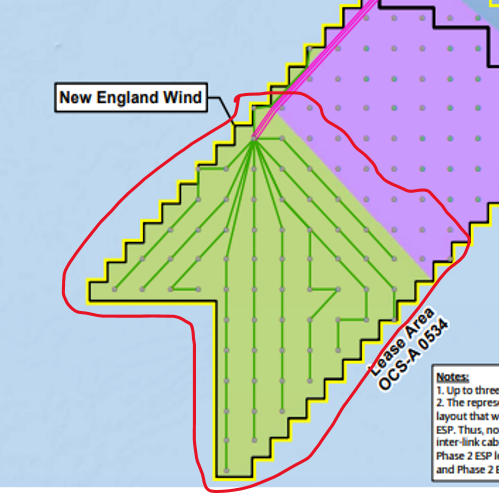

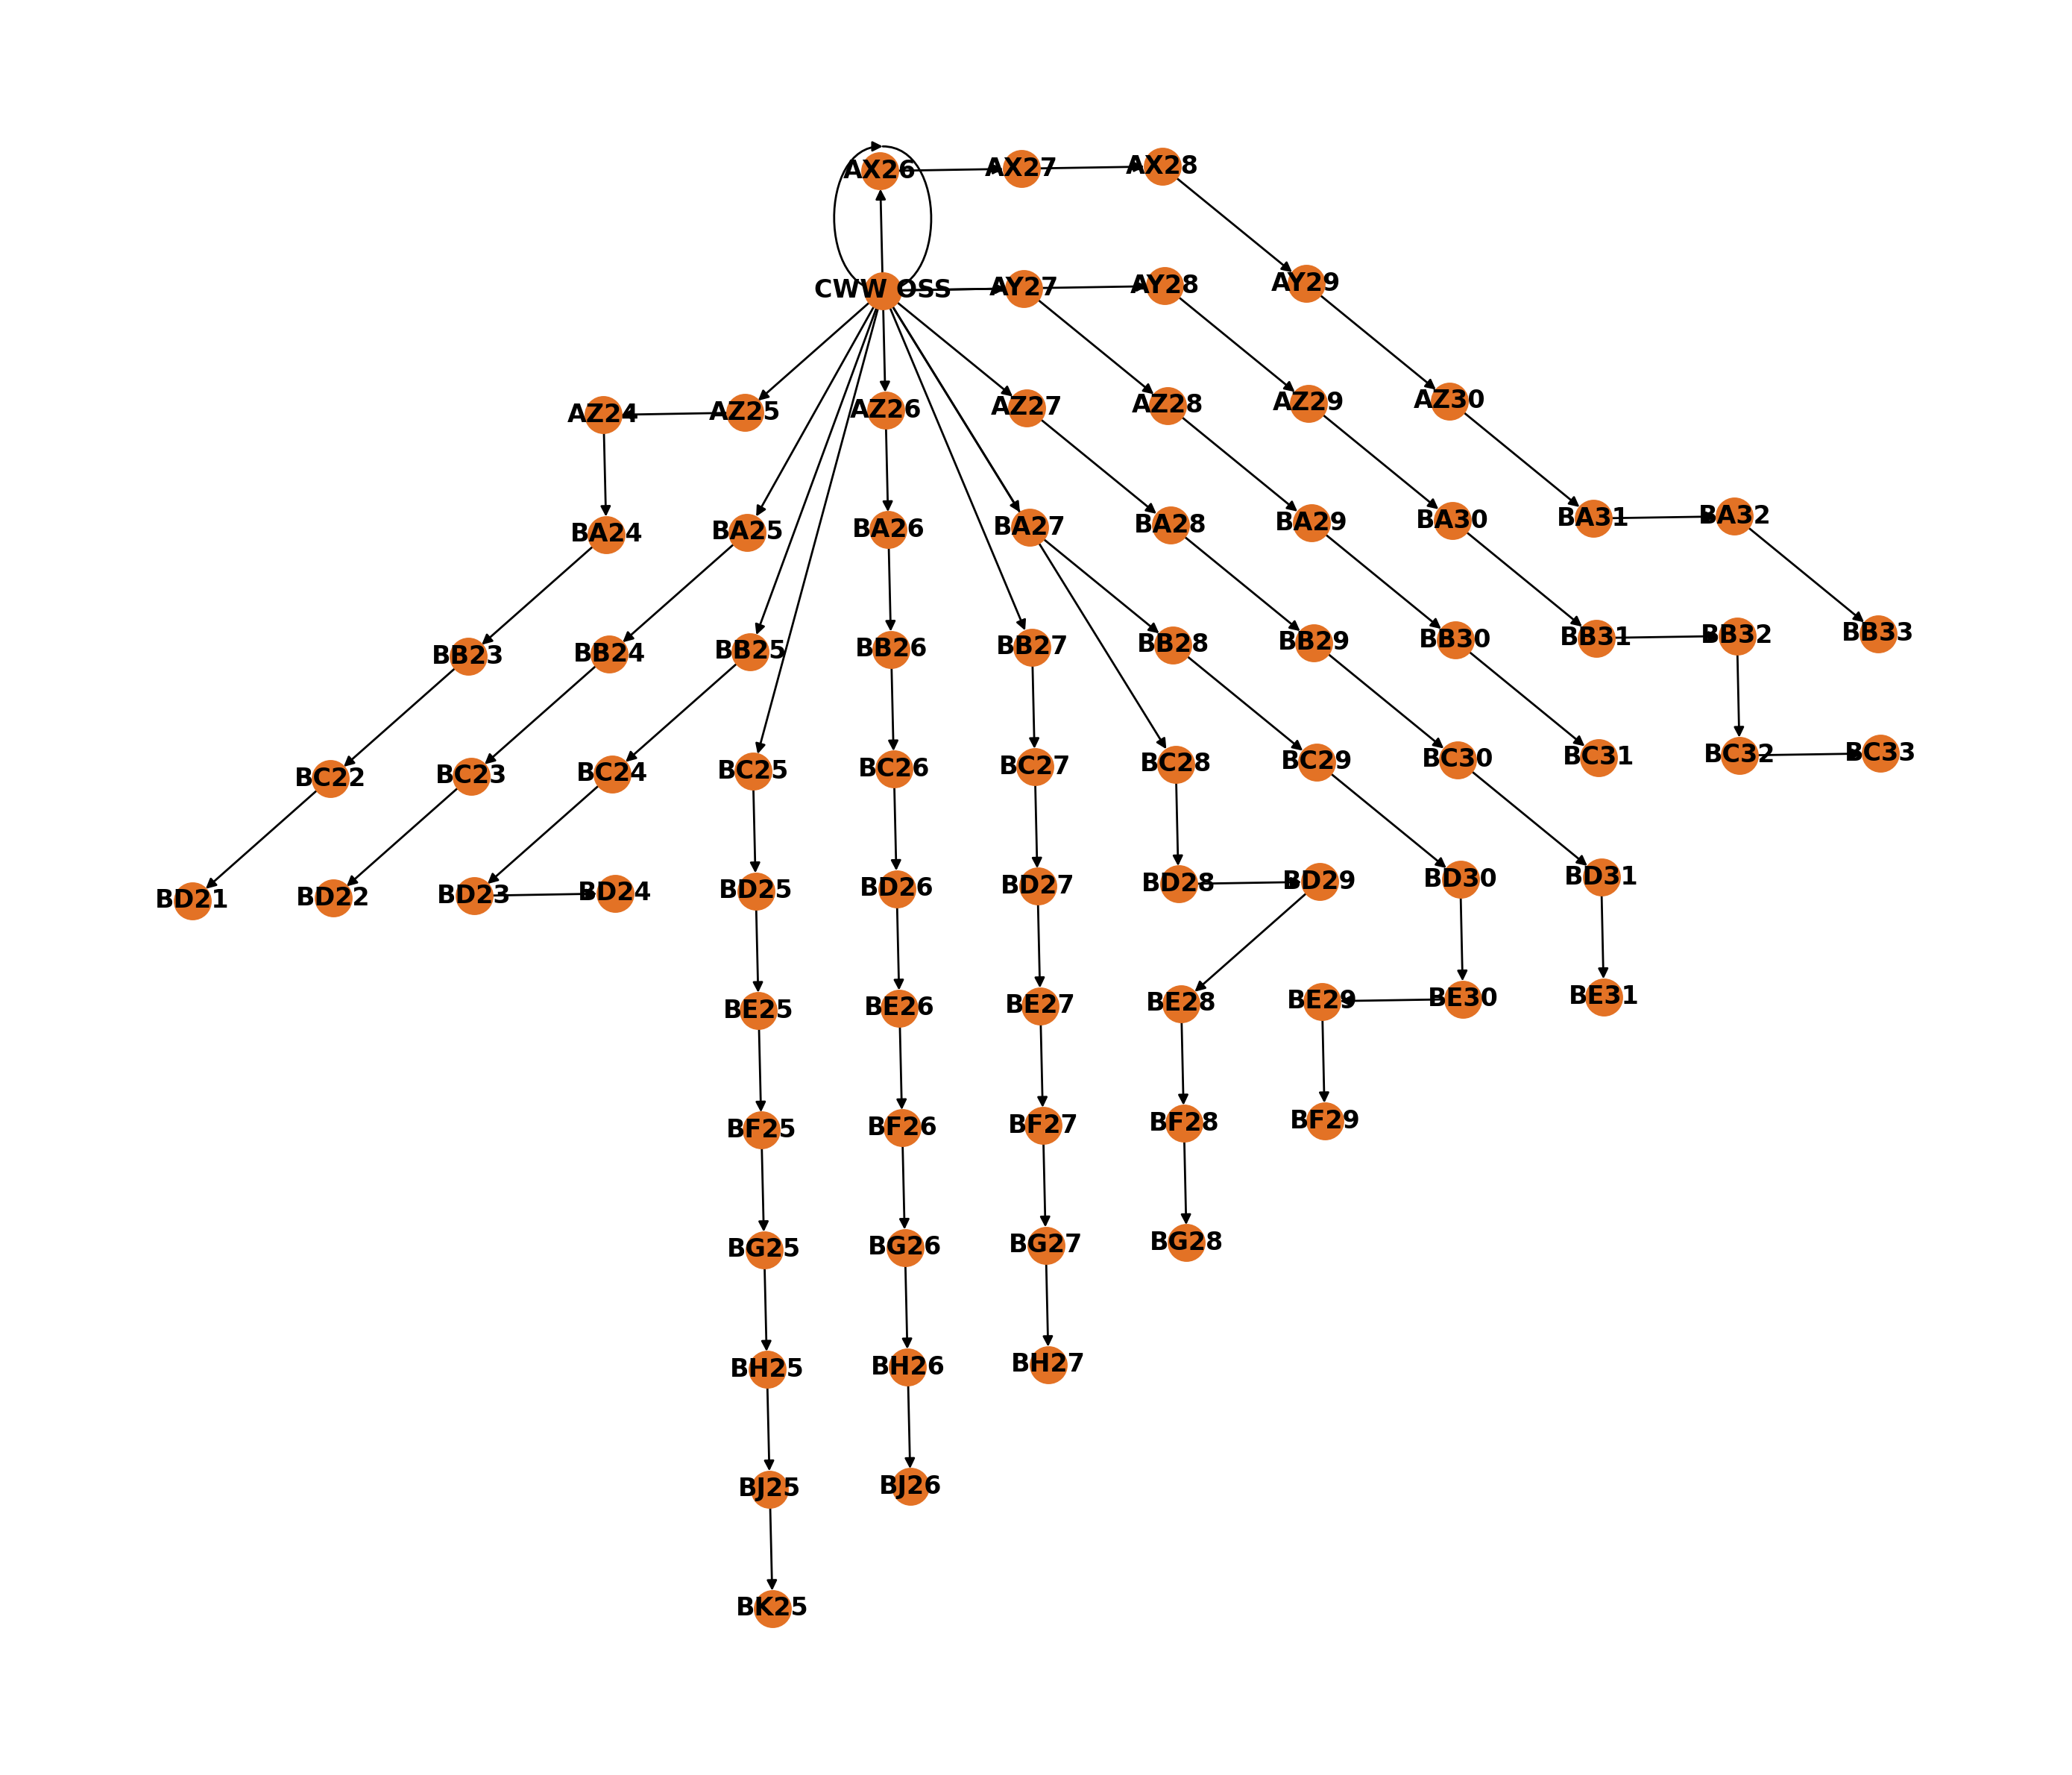

In [7]:
# Inspect the layout
fig, ax = project.plot_farm(return_fig=True)
fig.savefig(library_path / "results" / "Commonwealth_layout.svg")

## Run the analyses and calculate results

This separately calls the `run` methods for each of the ORBIT `ProjectManager` and WOMBAT `Simualation`, in that order. Alternatively, these could just be called on their own, just like we must with FLORIS for the time being.

**NOTE: In reality, it will need to be determined how we should actually run FLORIS to get the outputs that we want, so this usage is a crude placeholder**

In [6]:
project.run(
    skip="orbit",  # NOTE: There is an error in the Scouring Protection configuration
    which_floris="wind_rose",
    full_wind_rose=False,
    floris_reinitialize_kwargs=dict(cut_in_wind_speed=3.0, cut_out_wind_speed=25.0)
)

ValueError: too many values to unpack (expected 3)

In [ ]:
project.energy_production(frequency="project")

In [ ]:
project.capex()

In [ ]:
project.opex(frequency="project")

In [ ]:
project.npv(frequency="project")

# TODO: Results
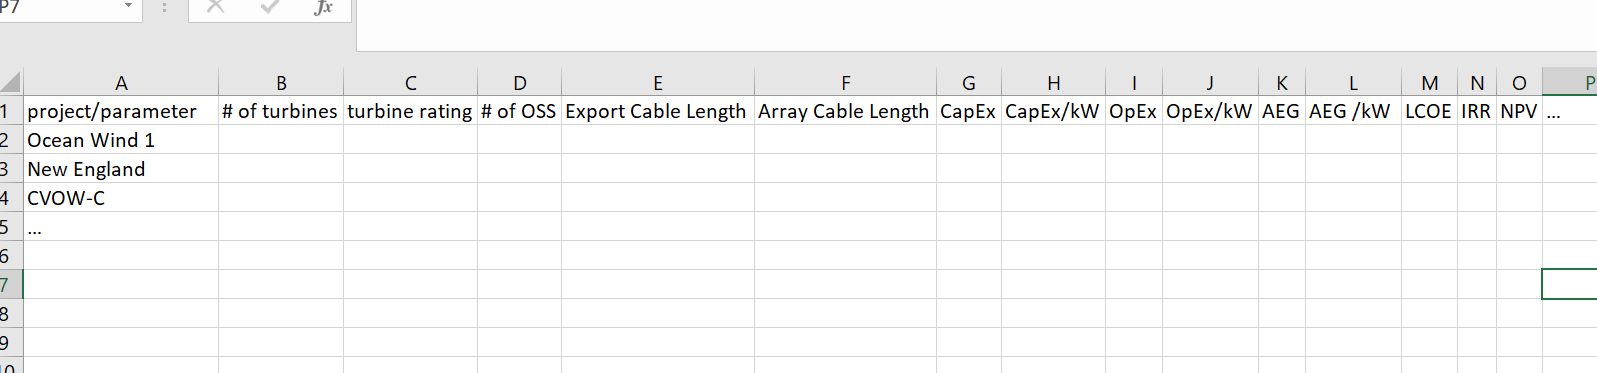

In [ ]:
# Note this will incorporated into a proper feature,
# NOTE: this will break because ORBIT isn't being run due to some odd issue with the scouring protection installation
results_option1 = pd.DataFrame(
    [
        project.orbit.num_turbines, 
        project.orbit.turbine_rating,
        project.orbit._phases["OffshoreSubstationDesign"].num_substations,
        project.export_system_total_cable_length(),
        project.array_system_total_cable_length(),
        project.capex(),
        project.capex() / project.orbit.total_capex_per_kw,
        project.opex(),
        project.opex().values[0, 0],
        # AEG
        # LCOE
        # IRR
        project.npv(frequency="project").values[0, 0]
    ],
    columns=[
        "# of turbines",
        "turbine rating",
        "# of OSS",
        "Export Cable Length",
        "Array Cable Length",
        "CapEx",
        "CapEx/kW",
        "OpEx",
        "OpEx/kW",
        # "AEG",
        # "AEG/kW",
        # "LCOE",
        "IRR",
        "NPV",
    ]
)
results_option_2 = pd.DataFrame(
    [
        project.wombat.windfarm.turbine_id.size, 
        project.wombat.windfarm.system(project.wombat.windfarm.turbine_id[0]).capacity,  # or do capacity / # turbines for average?
        project.wombat.windfarm.substation_id.size,
        project.export_system_total_cable_length(),
        project.array_system_total_cable_length(),
        project.capex(),
        project.capex() / project.orbit.total_capex_per_kw,
        project.opex(),
        project.opex().values[0, 0],
        # AEG
        # LCOE
        # IRR
        project.npv(frequency="project").values[0, 0]
    ],
    columns=[
        "# of turbines",
        "turbine rating",
        "# of OSS",
        "Export Cable Length",
        "Array Cable Length",
        "CapEx",
        "CapEx/kW",
        "OpEx",
        "OpEx/kW",
        # "AEG",
        # "AEG/kW",
        # "LCOE",
        "IRR",
        "NPV",
    ]
)